# GAAE Training — DELCODE DMN-Only (46 Nodes)

This notebook trains the GAAE model on DMN-only correlation matrices (46 nodes)
from `DATA/DELCODE/__v4__/dmn_only_schaefer`. It uses `GraphDMNDatasetInMemoryFiltered` (DMN file suffixes). It does a subject-level 60/20/20 train/val/test split via pre-generated CSVs. Lowered dimenstions namely the hyperparameters (`adjacency_k=8`, `latent_dim=32`)

## Imports

In [19]:
import os
import sys
import json
from datetime import datetime
from pathlib import Path

import random
import numpy as np
import torch
from torch_geometric.loader import DataLoader

# Project root
base_dir = Path('/mnt/e/fyassine/ad-early-detection/MODEL')
sys.path.insert(0, str(base_dir))

from model.GAAE.models import GraphAttentionAutoencoderConditioned
from model.GAAE.dataset import GraphDMNDatasetInMemoryFiltered
from model.GAAE.utils import knn_binary_adjacency_matrix_no_diag
from model.GAAE.train import train_model_with_val_notebook_train_loss

## Configuration

In [20]:
WANDB_PROJECT = "ad-early-detection-dmn"

try:
    import wandb
    wandb.login()
except Exception:
    wandb = None
    print("wandb not available — logging disabled")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Hyperparamaters

In [22]:
# Load hyperparameters
hyperparams_path = base_dir / "configs" / "gaae_delcode_dmn.json"
with open(hyperparams_path, "r") as handle:
    hyperparams = json.load(handle)

seed = hyperparams["seed"]
batch_size = hyperparams["batch_size"]
learning_rate = hyperparams["learning_rate"]
adj_loss_weight = hyperparams["adj_loss_weight"]
n_epochs = hyperparams["epochs"]
early_stopping_patience = hyperparams["early_stopping_patience"]

out_features = hyperparams["latent_dim"]
num_heads = hyperparams["num_heads"]
cond_dim = hyperparams["cond_dim"]
dropout = hyperparams["dropout"]
model_save_path = hyperparams.get("model_save_path")

adjacency_args = {"k": hyperparams["adjacency_k"]}
num_workers = hyperparams["num_workers"]
file_variant = hyperparams.get("file_variant", "z_transformed")

print(f"Hyperparameters: {json.dumps(hyperparams, indent=2)}")

Hyperparameters: {
  "seed": 100,
  "batch_size": 64,
  "learning_rate": 0.001,
  "adj_loss_weight": 0.1,
  "epochs": 1000,
  "early_stopping_patience": 100,
  "latent_dim": 32,
  "num_heads": 2,
  "cond_dim": 2,
  "dropout": 0.5,
  "adjacency_k": 8,
  "num_workers": 8,
  "file_variant": "z_transformed",
  "dense_use_abs": false,
  "model_save_path": null
}


In [23]:
# Set random seeds for reproducibility
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(seed)

def worker_init_fn(worker_id):
    worker_seed = seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

print(f"Random seed set to: {seed}")

Random seed set to: 100


## Dataset

In [ ]:
dmn_data_root = "/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/dmn_only_schaefer"

metadata_dir = "/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/metadata"
gaae_splits_dir = os.path.join(metadata_dir, "splits_gaae")
train_csv = os.path.join(gaae_splits_dir, "train.csv")
val_csv   = os.path.join(gaae_splits_dir, "val.csv")
test_csv  = os.path.join(gaae_splits_dir, "test.csv")

def clear_processed_cache(root, file_variant, split_name):
    variant_tag = str(file_variant).lower().replace("-", "_")
    processed_dir = os.path.join(root, "processed")
    processed_file = os.path.join(processed_dir, f"data_filtered_{variant_tag}_{split_name}.pt")
    if os.path.exists(processed_file):
        os.remove(processed_file)
        print(f"Removed stale processed cache: {processed_file}")

clear_processed_cache(dmn_data_root, file_variant, "train")
clear_processed_cache(dmn_data_root, file_variant, "val")
clear_processed_cache(dmn_data_root, file_variant, "test")

train_dataset = GraphDMNDatasetInMemoryFiltered(
    root=dmn_data_root,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    filter_csv_path=train_csv,
    separator=",",
    file_variant=file_variant,
)

val_dataset = GraphDMNDatasetInMemoryFiltered(
    root=dmn_data_root,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    filter_csv_path=val_csv,
    separator=",",
    file_variant=file_variant,
)

test_dataset = GraphDMNDatasetInMemoryFiltered(
    root=dmn_data_root,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    filter_csv_path=test_csv,
    separator=",",
    file_variant=file_variant,
)

print(f"Train: {len(train_dataset)} samples")
print(f"Val:   {len(val_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")
print(f"Feature shape: {train_dataset[0].x.shape}")

Removed stale processed cache: /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v5__/dmn_only_schaefer/processed/data_filtered_z_transformed_train.pt
Removed stale processed cache: /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v5__/dmn_only_schaefer/processed/data_filtered_z_transformed_val.pt
Removed stale processed cache: /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v5__/dmn_only_schaefer/processed/data_filtered_z_transformed_test.pt


Processing...
Done!
Processing...


Train: 447 samples
Val:   92 samples
Test:  59 samples
Feature shape: torch.Size([46, 46])


Done!
Processing...
Done!


In [25]:
# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    worker_init_fn=worker_init_fn,
    persistent_workers=True if num_workers > 0 else False,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    worker_init_fn=worker_init_fn,
    persistent_workers=True if num_workers > 0 else False,
    pin_memory=True if torch.cuda.is_available() else False
)

dataset_info = {
    "dataset_name": "DMN-only Schaefer 46-node (60/20/20 subject-level split)",
    "kNN_param": adjacency_args['k'],
    "correlation_type": file_variant,
    "num_features": train_dataset[0].x.size(1),
    "train_dataset_size": len(train_dataset),
    "val_dataset_size": len(val_dataset),
    "test_dataset_size": len(test_dataset),
    "batch_size": batch_size
}
print(f"Dataset info: {json.dumps(dataset_info, indent=2)}")

Dataset info: {
  "dataset_name": "DMN-only Schaefer 46-node (60/20/20 subject-level split)",
  "kNN_param": 8,
  "correlation_type": "z_transformed",
  "num_features": 46,
  "train_dataset_size": 447,
  "val_dataset_size": 92,
  "test_dataset_size": 59,
  "batch_size": 64
}


## Model

In [26]:
# Derive in_features from the dataset
in_features = train_dataset[0].x.size(1)
hidden_dim = in_features  # same as in_features by default

model = GraphAttentionAutoencoderConditioned(
    in_features=in_features,
    hidden_dim=hidden_dim,
    out_features=out_features,
    cond_dim=cond_dim,
    num_heads=num_heads,
    dropout=dropout
).to(device)

model_config = {
    "model_type": model.__class__.__name__,
    "in_features": in_features,
    "hidden_size": hidden_dim,
    "latent_dim": out_features,
    "attention_heads": num_heads,
    "device": device.type,
    "dropout": dropout
}

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(f"Model: {model.__class__.__name__}")
print(f"  in_features={in_features}, hidden_dim={hidden_dim}, out_features={out_features}")
print(f"  num_heads={num_heads}, dropout={dropout}")

Model: GraphAttentionAutoencoderConditioned
  in_features=46, hidden_dim=46, out_features=32
  num_heads=2, dropout=0.5


## Training

In [ ]:
USE_CHECKPOINT = False

CHECKPOINT_SEARCH_DIRS = [
    str(base_dir / "notebooks" / "checkpoints_gaae_dmn"),
]

if USE_CHECKPOINT:
    checkpoint_candidates = sorted(
        [
            (run_dir.name, str(model_file), str(run_dir))
            for checkpoint_dir in CHECKPOINT_SEARCH_DIRS
            for base_dir_path in [Path(checkpoint_dir)]
            if base_dir_path.is_dir()
            for run_dir in sorted(base_dir_path.iterdir())
            if run_dir.is_dir()
            for model_file in [run_dir / f"model_{run_dir.name}.pth"]
            if model_file.exists()
        ],
        key=lambda x: x[0],
    )

    if not checkpoint_candidates:
        raise FileNotFoundError(
            "No GAAE checkpoints found. Train first or set USE_CHECKPOINT=False."
        )

    print("Available GAAE checkpoints:")
    for i, (run_name, _, run_dir) in enumerate(checkpoint_candidates):
        print(f"  {i}: {run_name} ({run_dir})")

    selected_run_index = int(input("Select a checkpoint by index: "))
    SELECTED_RUN_NAME, GAAE_CHECKPOINT_PATH, SELECTED_RUN_DIR = checkpoint_candidates[selected_run_index]

    checkpoint_obj = torch.load(GAAE_CHECKPOINT_PATH, map_location=device)
    if isinstance(checkpoint_obj, torch.nn.Module):
        model = checkpoint_obj.to(device)
    elif isinstance(checkpoint_obj, dict):
        model.load_state_dict(checkpoint_obj)
        model = model.to(device)
    else:
        raise TypeError("Unsupported checkpoint format. Expected torch.nn.Module or state_dict.")

    best_model = model
    history = {"train_loss": [], "val_loss": []}
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    run_name = f"checkpoint_{SELECTED_RUN_NAME}_{run_timestamp}"
    print(f"Loaded checkpoint from {GAAE_CHECKPOINT_PATH}")
    print("Training skipped because USE_CHECKPOINT=True")
else:
    best_model, history = train_model_with_val_notebook_train_loss(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        batch_size=batch_size,
        learning_rate=learning_rate,
        model_config=model_config,
        adj_loss_weight=adj_loss_weight,
        epochs=n_epochs,
        early_stopping_patience=early_stopping_patience,
        dataset_info=dataset_info,
        project_name=WANDB_PROJECT
    )

    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    try:
        wandb_run_name = wandb.run.name if wandb and wandb.run and wandb.run.name else "run"
    except Exception:
        wandb_run_name = "run"
    wandb_run_name = str(wandb_run_name).replace(" ", "-")
    run_name = f"{wandb_run_name}_{run_timestamp}"

    checkpoint_root = base_dir / "notebooks" / "checkpoints_gaae_dmn"
    os.makedirs(checkpoint_root, exist_ok=True)
    run_artifact_dir = checkpoint_root / run_name
    os.makedirs(run_artifact_dir, exist_ok=True)

    model_file = run_artifact_dir / f"model_{run_name}.pth"
    torch.save(best_model, str(model_file))
    print(f"Saved best model to {model_file}")

    config_to_save = {
        "run_name": run_name,
        "wandb_run_name": wandb_run_name,
        "timestamp": run_timestamp,
        "dataset_info": dataset_info,
        "model_config": model_config,
        "training_config": {
            "batch_size": batch_size,
            "learning_rate": learning_rate,
            "adj_loss_weight": adj_loss_weight,
            "epochs": n_epochs,
            "early_stopping_patience": early_stopping_patience
        }
    }

    def json_serial(obj):
        if isinstance(obj, (datetime, torch.device)):
            return str(obj)
        raise TypeError(f"Type {type(obj)} not serializable")

    config_file = run_artifact_dir / "run_config.json"
    with open(config_file, "w") as f:
        json.dump(config_to_save, f, indent=4, default=json_serial)
    print(f"Saved run configuration to {config_file}")

Train Loss,█▆▆▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁
Val Loss,█▇▇▆▆▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁
Train Loss,0.03512
Val Loss,0.03175


Training Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved best model to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae/exalted-terrain-7_2026-03-23_11-18-48/model_exalted-terrain-7_2026-03-23_11-18-48.pth
Saved run configuration to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae/exalted-terrain-7_2026-03-23_11-18-48/run_config.json


## Loss Curves

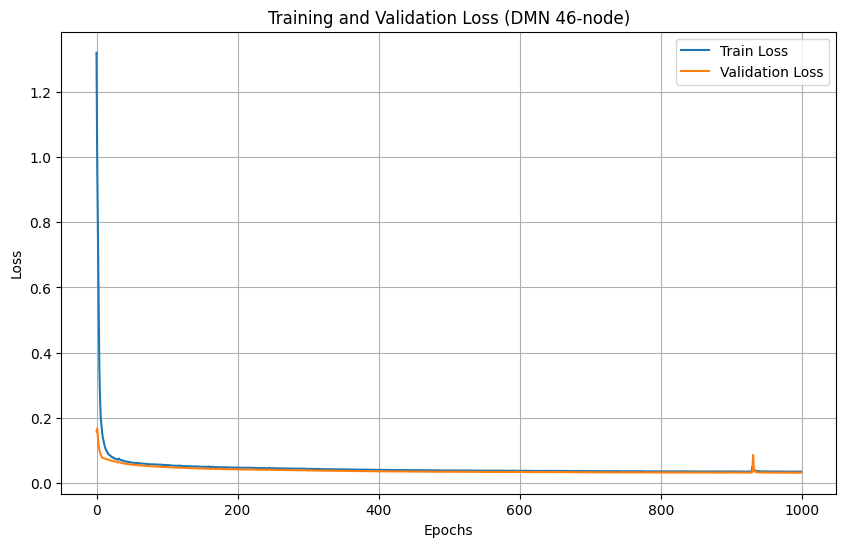

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (DMN 46-node)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Box Plots

/tmp/ipykernel_218859/648527547.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_218859/648527547.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


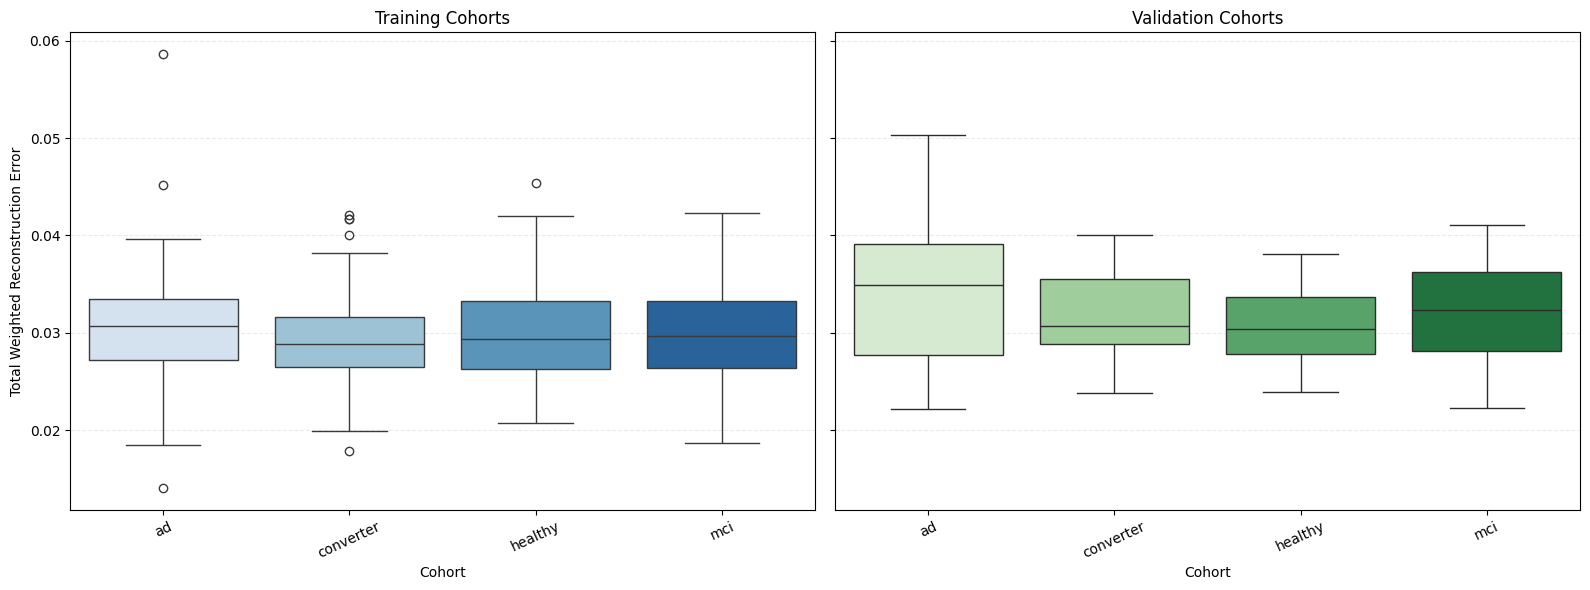

Train cohort counts:
Cohort
ad            77
converter    146
healthy      150
mci           74
dtype: int64

Validation cohort counts:
Cohort
ad           16
converter    31
healthy      30
mci          15
dtype: int64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj

from model.GAAE.utils import calculate_dense_adjacency

train_split_df = pd.read_csv(train_csv)
val_split_df = pd.read_csv(val_csv)

assert "Repseudonym" in train_split_df.columns and "diagnosis" in train_split_df.columns
assert "Repseudonym" in val_split_df.columns and "diagnosis" in val_split_df.columns

allowed_cohorts = {"ad", "converter", "healthy", "mci"}

combined_split_df = pd.concat([train_split_df, val_split_df], ignore_index=True)
subject_cohort_map = (
    combined_split_df[["Repseudonym", "diagnosis"]]
    .drop_duplicates(subset=["Repseudonym"], keep="first")
    .assign(
        Repseudonym=lambda d: d["Repseudonym"].astype(str).str.strip(),
        diagnosis=lambda d: d["diagnosis"].astype(str).str.lower().str.strip(),
    )
    .set_index("Repseudonym")["diagnosis"]
    .to_dict()
)

def compute_split_errors_by_cohort(dataset, split_name):
    records = []
    unknown_ids = []
    model.eval()

    for data in dataset:
        data = data.to(device)
        x, edge_index, edge_attr = data.x, data.edge_index, getattr(data, "edge_attr", None)
        patient_id = str(getattr(data, "patient_id", "")).strip()
        cohort = subject_cohort_map.get(patient_id)

        if cohort not in allowed_cohorts:
            unknown_ids.append(patient_id)
            continue

        cond_vec = torch.tensor(
            [[data.patient_age.item(), float(data.patient_sex.item())]],
            device=device,
        )
        batch_mask = torch.zeros(x.size(0), dtype=torch.long, device=device)

        with torch.no_grad():
            _, x_reconstructed, adj_reconstructed, _ = model(
                x, edge_index, edge_attr, cond_vec, batch_mask
            )

        x_error = F.mse_loss(x_reconstructed, x).item()
        adj_original = calculate_dense_adjacency(data).to(device)
        adj_reconstructed_dense = to_dense_adj(
            edge_index, edge_attr=adj_reconstructed, max_num_nodes=x.size(0)
        ).squeeze(0)
        adj_error = F.binary_cross_entropy(adj_reconstructed_dense, adj_original).item()
        total_error = x_error + adj_loss_weight * adj_error

        records.append(
            {
                "Split": split_name,
                "Cohort": cohort,
                "Total Error": total_error,
            }
        )

    if unknown_ids:
        unique_unknown = sorted(set(unknown_ids))
        raise ValueError(
            f"{split_name}: found {len(unique_unknown)} IDs without allowed diagnosis mapping. "
            f"Examples: {unique_unknown[:10]}"
        )

    return pd.DataFrame(records)

train_errors_df = compute_split_errors_by_cohort(train_dataset, "Train")
val_errors_df = compute_split_errors_by_cohort(val_dataset, "Validation")

cohort_order = [
    c for c in ["ad", "converter", "healthy", "mci"]
    if c in set(train_errors_df["Cohort"]) | set(val_errors_df["Cohort"])
]

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

split_frames = [
    ("Train", train_errors_df, "Blues"),
    ("Validation", val_errors_df, "Greens"),
]

for split_name, split_df, palette_name in split_frames:
    plt.figure(figsize=(10, 7))
    ax = plt.gca()

    sns.swarmplot(
        data=split_df,
        x="Cohort",
        y="Total Error",
        order=cohort_order,
        color=".25",
        size=4,
        alpha=0.6,
        zorder=1,
        ax=ax,
    )

    boxplot = sns.boxplot(
        data=split_df,
        x="Cohort",
        y="Total Error",
        order=cohort_order,
        palette=palette_name,
        showcaps=True,
        boxprops={"edgecolor": "black", "linewidth": 2},
        medianprops={"color": "red", "linewidth": 2.5},
        whiskerprops={"color": "black", "linewidth": 2},
        capprops={"color": "black", "linewidth": 2},
        zorder=2,
        ax=ax,
    )

    alpha_value = 0.5
    for patch in boxplot.patches:
        facecolor = patch.get_facecolor()
        if len(facecolor) == 4:
            r, g, b, _ = facecolor
        else:
            r, g, b = facecolor[:3]
        patch.set_facecolor((r, g, b, alpha_value))

    y_top = split_df["Total Error"].max()
    y_min = split_df["Total Error"].min()
    y_span = y_top - y_min if y_top > y_min else 1.0
    ax.set_ylim(y_min - 0.05 * y_span, y_top + 0.18 * y_span)

    for i, cohort in enumerate(cohort_order):
        cohort_data = split_df[split_df["Cohort"] == cohort]["Total Error"]
        if cohort_data.empty:
            continue
        mean_val = cohort_data.mean()
        std_val = cohort_data.std(ddof=1) if len(cohort_data) > 1 else 0.0
        ax.text(
            i,
            y_top + 0.12 * y_span,
            f"μ={mean_val:.4f}\nσ={std_val:.4f}",
            ha="center",
            va="top",
            fontsize=9,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8),
        )

    ax.set_title(f"{split_name} Cohorts", fontsize=16, fontweight="bold")
    ax.set_xlabel("Cohort", fontsize=14)
    ax.set_ylabel("Total Weighted Reconstruction Error", fontsize=14)
    ax.tick_params(axis="x", rotation=25, labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    display_run_name = globals().get("run_name", globals().get("wandb_run_name", "run"))
    plt.figtext(
        0.99,
        0.01,
        f"Project: {WANDB_PROJECT}, Run: {display_run_name}",
        horizontalalignment="right",
        verticalalignment="bottom",
        fontsize=6,
        alpha=0.5,
    )

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

print("Train cohort counts:")
print(train_errors_df.groupby("Cohort").size().sort_index())

print("\nValidation cohort counts:")
print(val_errors_df.groupby("Cohort").size().sort_index())